# ML Pipeline, Evaluation & Resampling



## Concepts Learned

1. Bais vs Variance
    * Bias - How well a model can fit the training data
    * Variance - How well a model can fit all data
2. Cross Validation
    * A Resampling techique that uses existing data to figure how well a model can perform.
    * KFlod Cross Validation -  Breaks the dataset into n amount of chucks and certain amount of chunks for training and testing. It does repeteadly for n amount of times, givings us an array of merctric allowing us to understand how well the model actuall perform.
    * Stratified K-Fold Cross-Validation - A version of KFLod Cross Validation where each chunk maintains the same ratio of values as the original datset.  
3. Confusion Matrix
    * Rows - Represent Prediction
    * Columns - Represent Actual Value
4. Sensitivity and specificity
    * Sensitivity - % of Positives a model got correct
    * Specificity - % of Negatives a model got correct
    * When a model is binary, there is only 1 specicifty and sensitvity value. However, model with more than 2 outcomes, has a Sensitivity and Specificity value for each outcome
5. ROC & AUC
    * ROC is a graph where x is speficiity and y is sensitity, in normal cases. Each point is represents a certaining threshold for model. 
    * The Integeral of ROC Function. Represent the area of under the ROC. A higher ROC is better.
    * Using ROC and AOC you can compare different models to find the best one. 

## Deliverable Project

* load data
* create pipeline
* Cross Validation
* classification report
* ROC AND AUC

In [40]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

In [42]:
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

In [43]:
X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.2, shuffle=True)

In [44]:
scaler = StandardScaler()
lr = LogisticRegression()
pipeline = Pipeline([
    ('scaling', scaler),
    ('model', lr)
])

In [45]:
k_config = StratifiedKFold(n_splits=5, shuffle=True)
scores = cross_val_score(pipeline, X_train, y_train, cv=k_config)
print(f"Mean Accuray: {np.mean(scores)}")
print(f"Standard Deviation of Accuray: {np.std(scores)}")

Mean Accuray: 0.9758241758241759
Standard Deviation of Accuray: 0.014578570507056687


In [46]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaling', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [47]:
y_preds = pipeline.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       1.00      0.99      0.99        77

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [50]:
y_pred_logits = pipeline.decision_function(X_train)

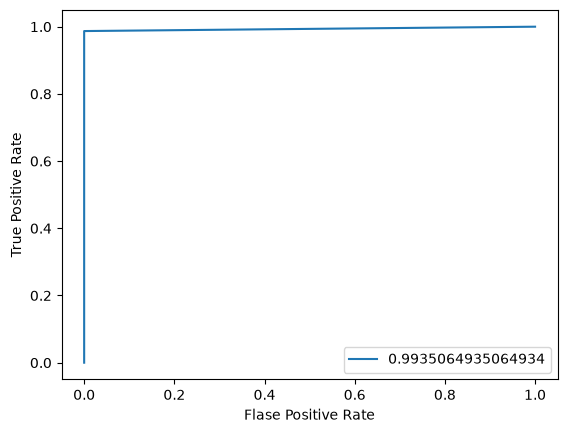

In [54]:
fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_preds)
auc_score = auc(fpr, tpr)


plt.plot(fpr, tpr, label=auc_score)
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
